# GPR Placed Above a Homogeneous Earth

In this notebook we take a look at `elfe3D_GPR`'s solution to a two-media model: air and a homogeneous earth.

## 1. Imports and Path Configuration

In [ ]:
import sys, os
from pathlib import Path

# inputs
from elfe3d_gpr.inputs.survey import GPRSurvey

# runner
from elfe3d_gpr.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr.outputs.fieldreader import AnalyticalLoader, ElfeLoader, load_elfe_batch
from elfe3d_gpr.outputs.postprocess import field_error, all_errors, error_stats
from elfe3d_gpr.outputs.visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot)

MASTER_PATH = (Path("..") / "elfe3D_GPR").resolve() # Base path variable, optional but convenient.

paths = ProjectPaths(
    master_dir = MASTER_PATH,   # Path where the elfe3D_GPR executable is located. Currently it is the same as repository root.
    exec_rel   = "",            # Relative path to find the executable. With the default installation it exists in the repository root, hence an empty string.
    use_wsl    = True,          # False if running the notebook from native Linux.
)

# Prints to verify that the paths are correct.
# print('Solver root:', MASTER_PATH)
# print('Executable:', paths.exec_path())


Solver root: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR


## 2: Generating the Geophysical Model

We will use the same geometrical model as the first example notebook, except change the dielectric parameters of the material below the origin of the model.

This material is set to have a relative electric permittivity $\varepsilon_r$ of $4$, electrical conductivity $\sigma$ of $1e\text{-}4$ S/m, and is non-magnetic.

In [ ]:
f    = 100e6        # Single Frequency Simulation
wave = 3e8 / f

survey = GPRSurvey.build(
    experiment_name = 'homogeneous_earth',
    base_dir        = MASTER_PATH,

    # Domain
    x_e = [-wave/10, 1 + wave/10],
    y_e = [-wave/10,     wave/10],
    z_e = [-wave/10,     wave/10],

    # Materials
    air_eps_r = 1.0,
    air_sigma = 1e-16,
    layer_thicknesses = [wave/10],
    layer_eps_r       = [4.0],      # Assigning the homogeneous earth material parameters
    layer_sigma       = [1e-4], 
    layer_mu_r        = [1.0],
    layer_sigma_m     = [0.0],

    # Source
    f_list              = [f],
    antenna_position    = [0.0, 0.0, 0.025],
    source_type         = 6,
    current_direction   = 1,
    num_segments        = 1,
    s_f                 = 250,
    bh_f                = 1.0,
    box_present         = False,
    box_x               = [-1 + 0.75, 1 + 0.375],

    # Receivers
    num_receivers_inline  = 48,
    num_receivers_endfire = 0,
    num_receivers_oblique = 0,

    # Solver
    solver_type      = 2,
    max_ref_steps    = 0,
    max_unknowns     = 5_000_000,
    accuracy_tol     = 3e-5,
    output_fields_vtk = 1,

    # PML
    num_pml_layers      = 1,
    pml_layer_thickness = wave/10,
    pml_type            = 'lin',
    pml_decay_type      = 1,

    least_samples_per_wavelength = 20, 
)

survey.generate()
print('poly :', survey.io.poly_file)


odepths: [np.float64(0.0375), np.float64(0.01875)]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
[0.0]
Input generation complete.
poly : F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_homogeneous_earth.poly


It should be noted that the `least_samples_per_wavelength` variable has a lower value of $20$ in this simulation than in the first example ($40$). That is because it is found to be a sufficient discretization level in terms of accuracy vs the semi-analytical solution of homogeneous earth.

## 3. Mesh generation with `tetgen`

We generate the mesh based on the inputs - same as before.

In [4]:
run_tetgen(paths, survey.io.poly_file)

Opening GPR_model_homogeneous_earth.poly.
Delaunizing vertices...
Delaunay seconds:  0.002444
Creating surface mesh ...
Surface mesh seconds:  0.001173
Constrained Delaunay...
Constrained Delaunay seconds:  0.001792
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000217
Refining mesh...
Refinement seconds:  1.32565
Optimizing mesh...
Optimization seconds:  0.062053

Writing GPR_model_homogeneous_earth.1.node.
Writing GPR_model_homogeneous_earth.1.ele.
Writing GPR_model_homogeneous_earth.1.face.
Writing GPR_model_homogeneous_earth.1.edge.
Writing GPR_model_homogeneous_earth.1.vtk.
Writing GPR_model_homogeneous_earth.1.neigh.

Output seconds:  1.06264
Total running seconds:  2.45606

Statistics:

  Input points: 226
  Input facets: 118
  Input segments: 329
  Input holes: 0
  Input regions: 36

  Mesh points: 65008
  Mesh tetrahedra: 390603
  Mesh faces: 786469
  Mesh edges: 460873
  Mesh faces on facets: 45412
  Mesh edges on segments: 191

## 4. Run the Fortran solver

We now have all simulation inputs ready. Hence, we can run the simulation now.

In [5]:
run_solver(paths,survey)

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions
Your input meshfile is called
 in/GPR_model_homogeneous_earth.                   
Your mesh has
       65008 Nodes
      390603 Elements
      460873 Edges (dof)
*************************************
Assembling connectivity arrays
Calculating interpolation coefficients
Obtaining model properties
*************************************
Source parameters:
 CSTYPE           6
 source-start coordinates:
  -1.4999999999999999E-004   0

## 5. Load solver results
Once the simulation is completed running, `elfe3d_gpr_io` can read the results.

In [ ]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR homogeneous earth',
    num_endfire = 48,
).endfire()

print(f'r : {ef.r.min():.3f} - {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_homogeneous_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## 6: Load analytical reference solution for the homogeneous half-space model.

A semi-analytical solution for this model has been evaluated and stored in the data folder. This is now read by the `elfe3d_gpr_io`'s `AnalyticalLoader` class.

In [ ]:
ANALYTICAL_DIR = (Path("..") / "data"/ "data_semi_analytical").resolve()    # Directory for where to find the analytical reference data.

# Loading the analytical equivalent to the simulation.
semi_analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_4_100MHz_NR.csv'),
    label='semi_analytical',
).endfire()

## 7: Compare computed field to analytical reference

### 7.1. Plotting the base receiver-line data against analytical solution

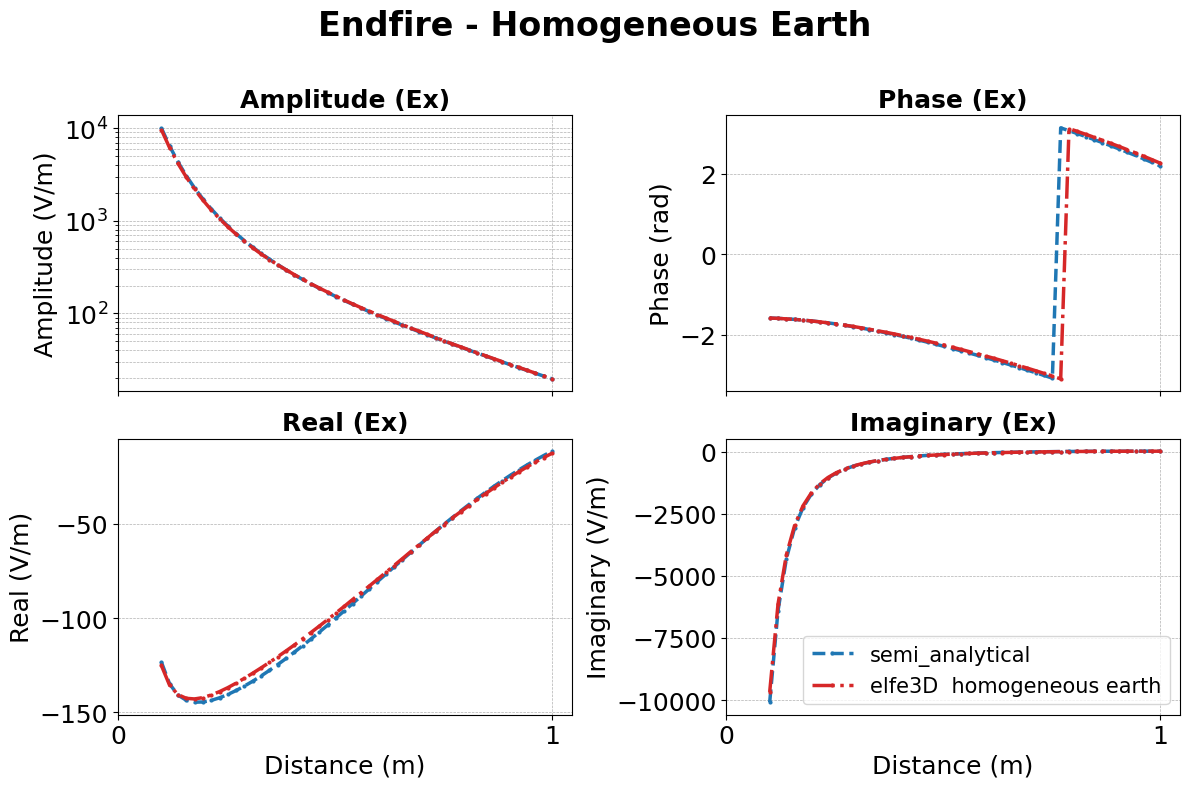

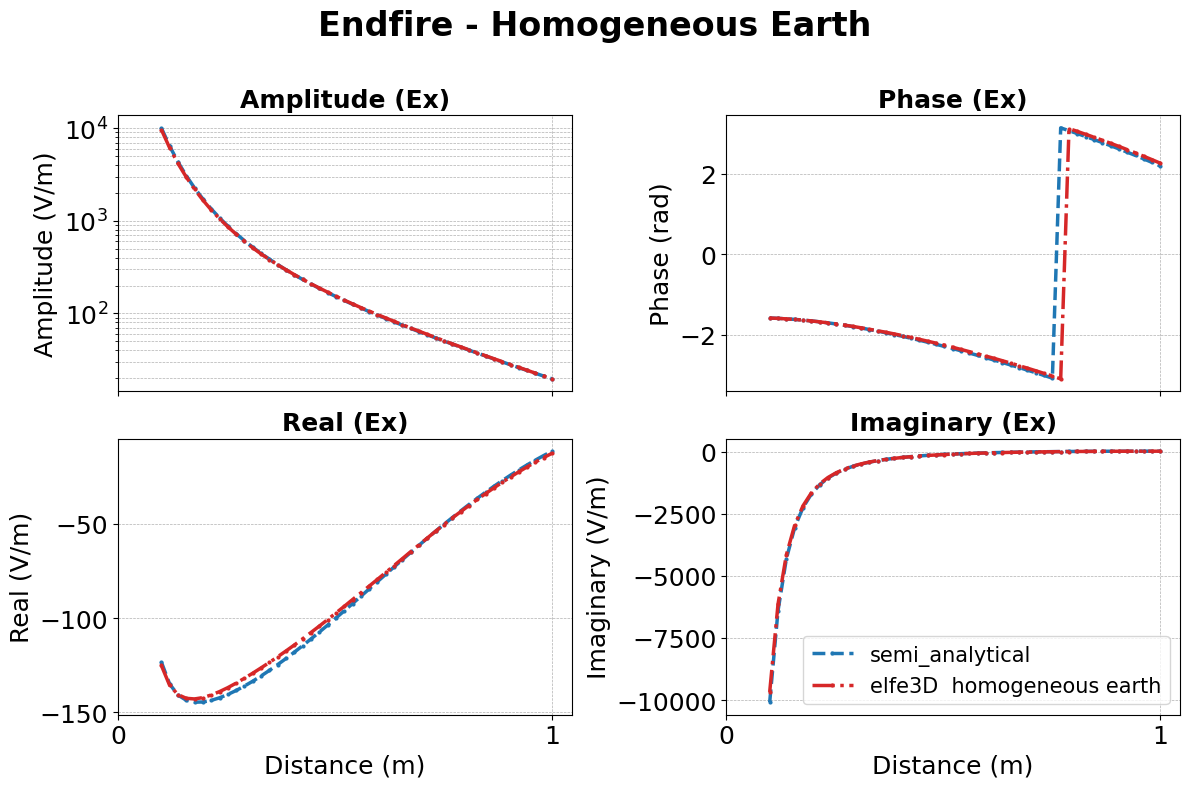

In [8]:
ReceiverLinePlot([semi_analytical, ef]).plot(suptitle="Endfire - Homogeneous Earth")

### 6.2 Error plot and quality check

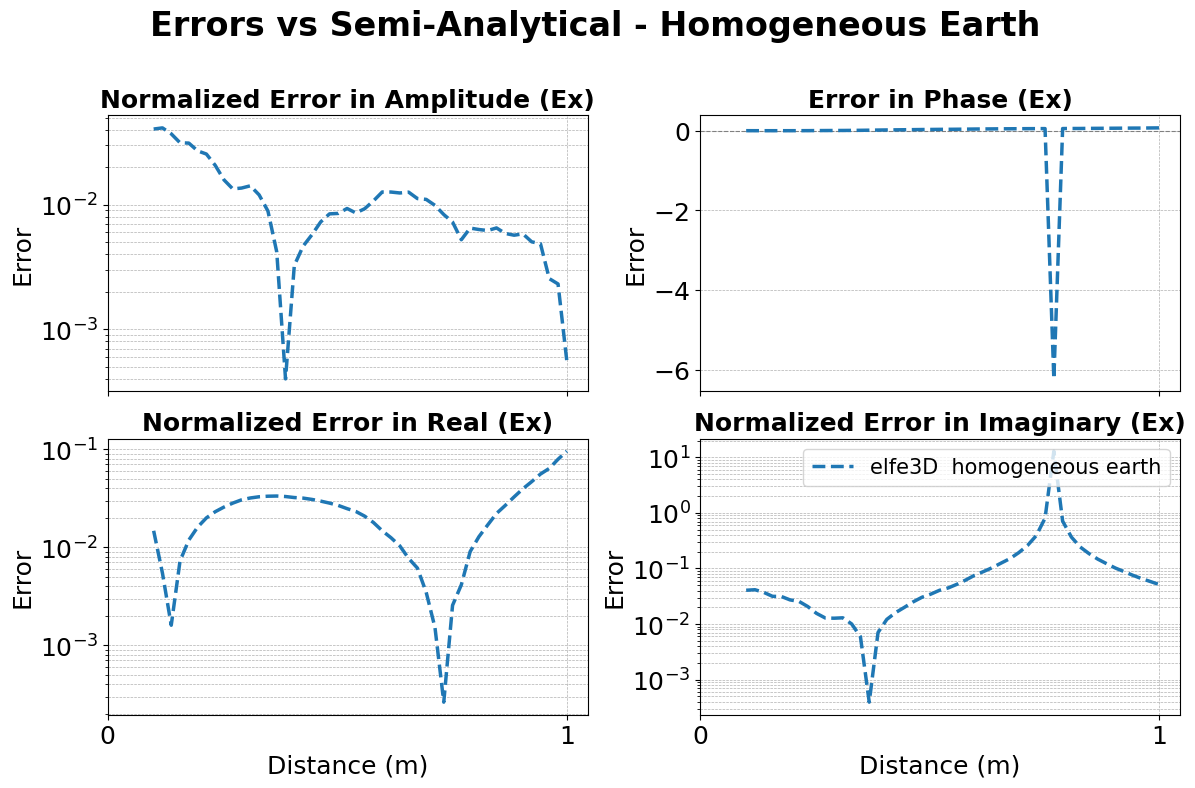

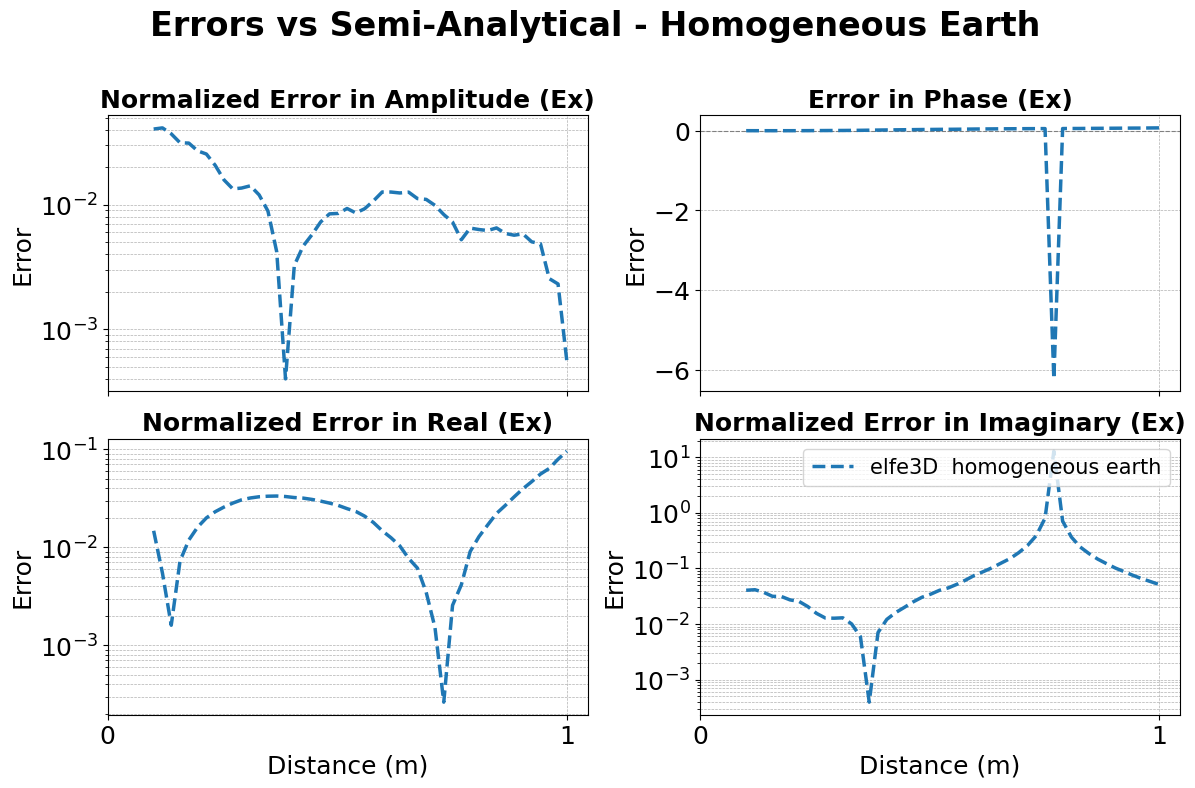

In [9]:
ReceiverLineErrorPlot([ef], reference=semi_analytical).plot(suptitle="Errors vs Semi-Analytical - Homogeneous Earth")

### 6.3 Combined field and error plot

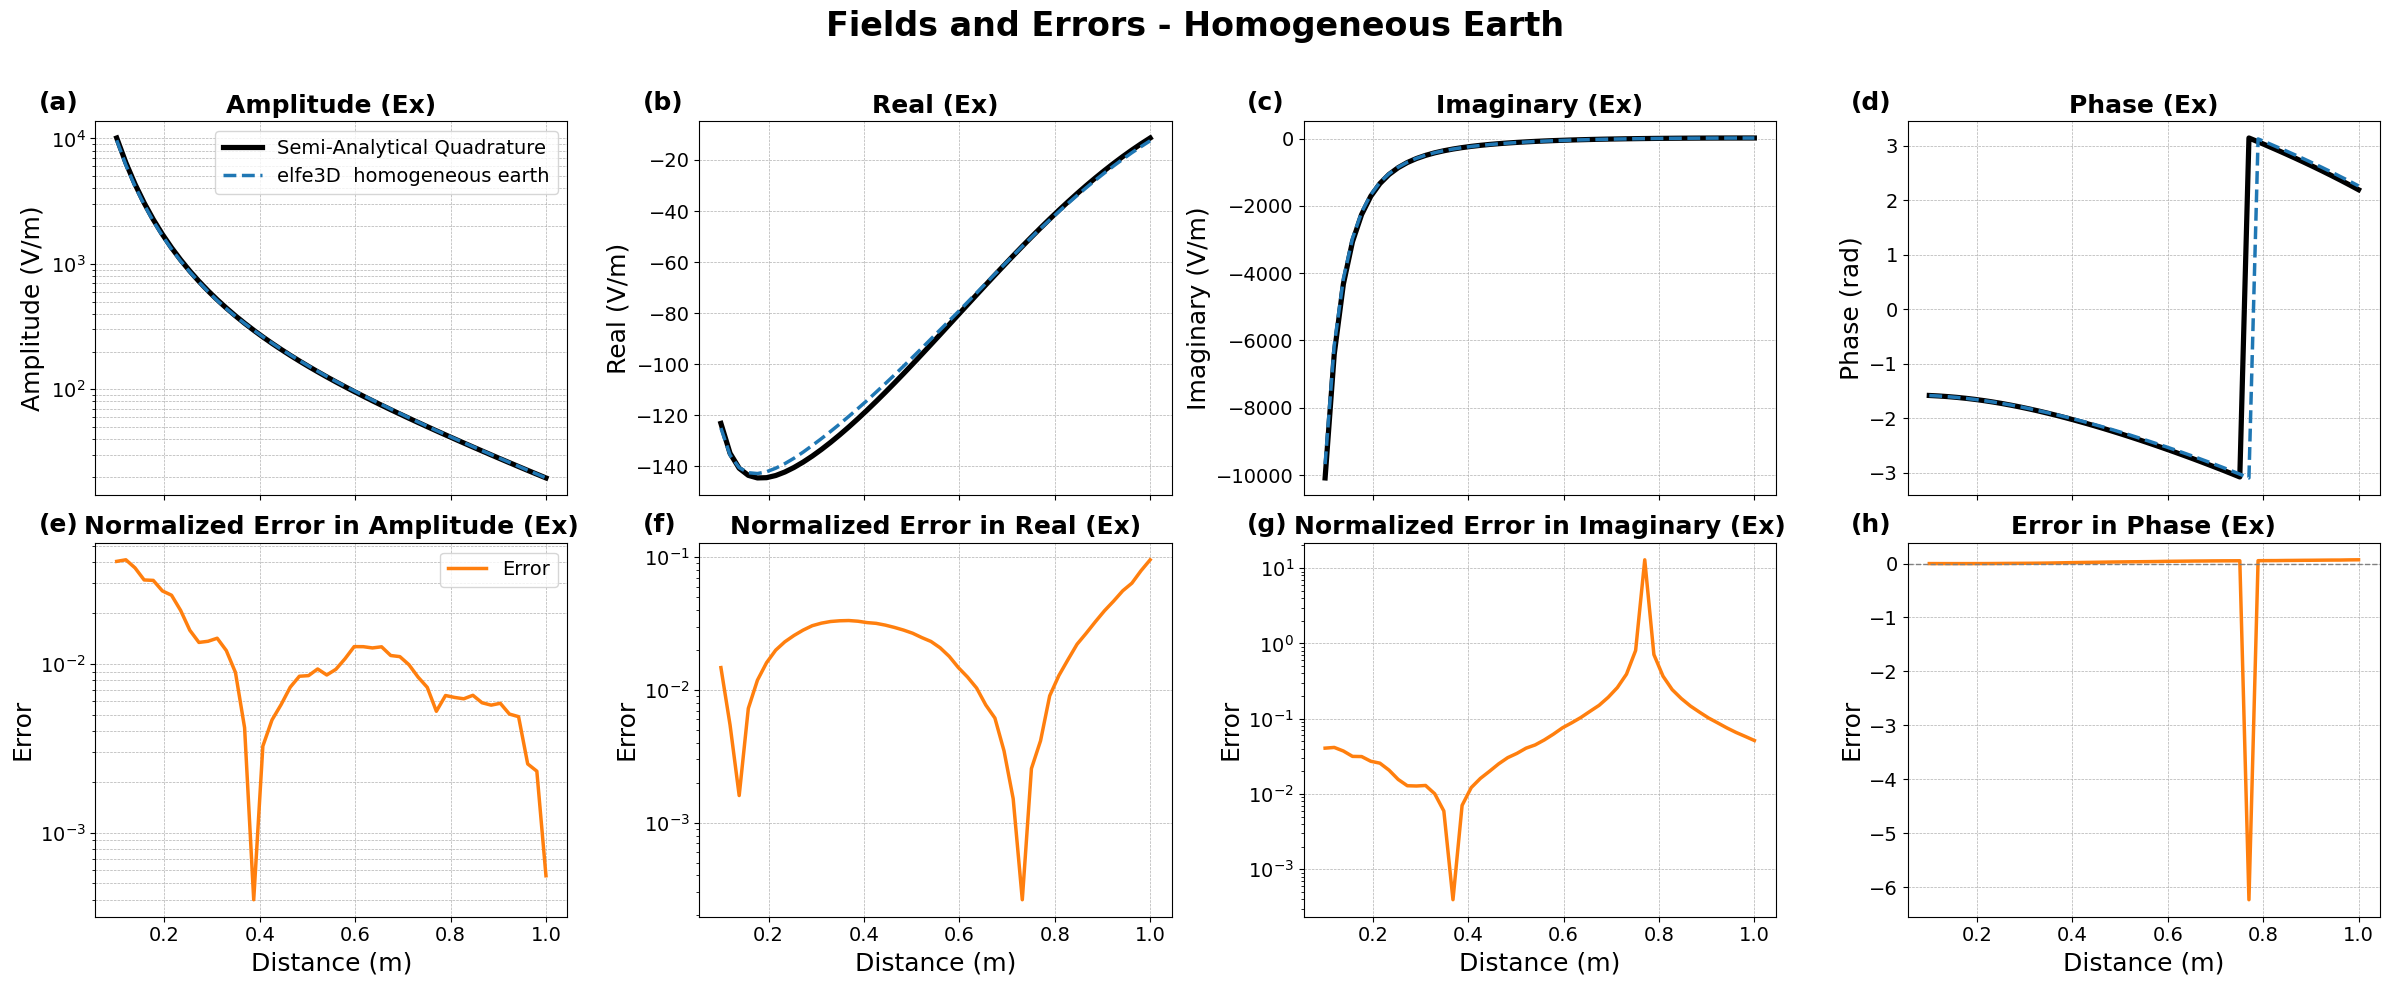

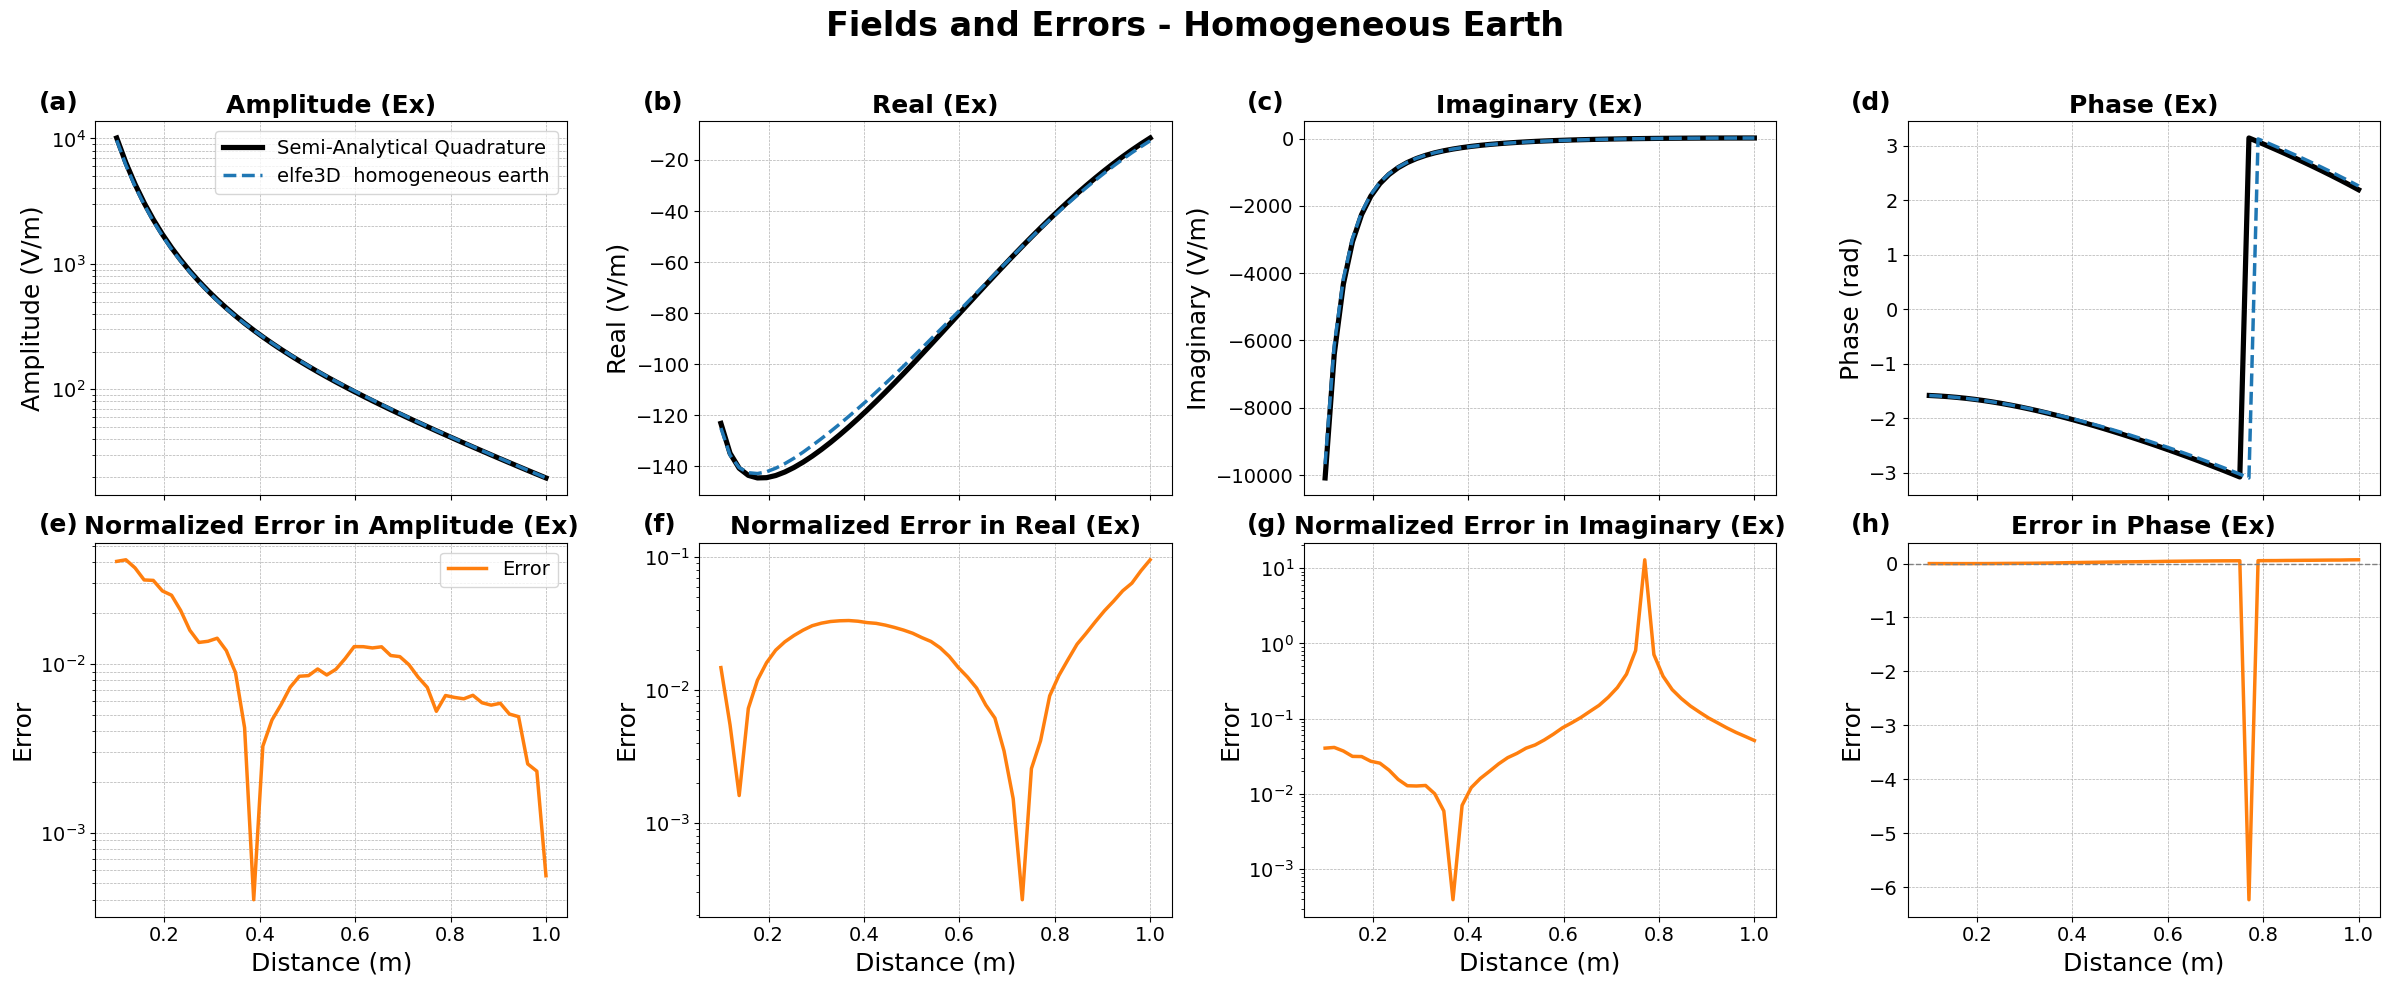

In [10]:
ReceiverLineCombined(ef, semi_analytical).plot(suptitle="Fields and Errors - Homogeneous Earth")

### 6.4. Error distribution histogram

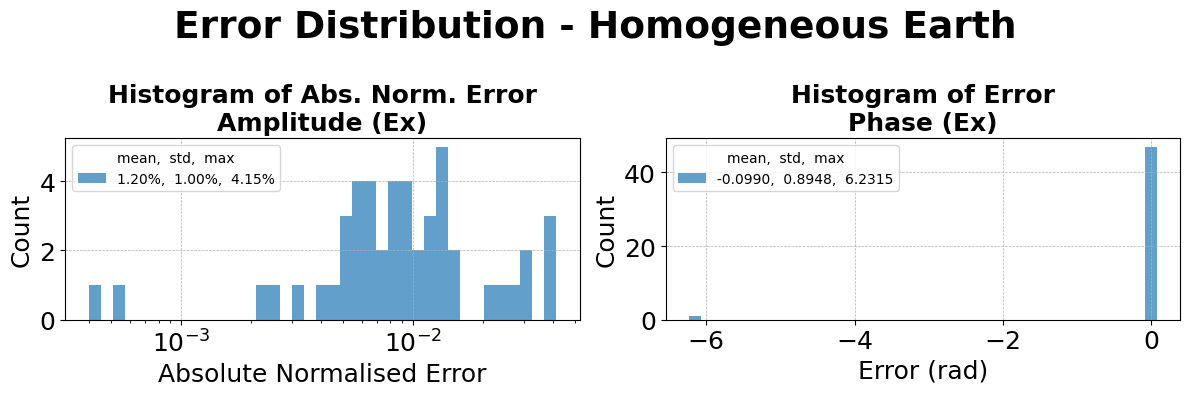

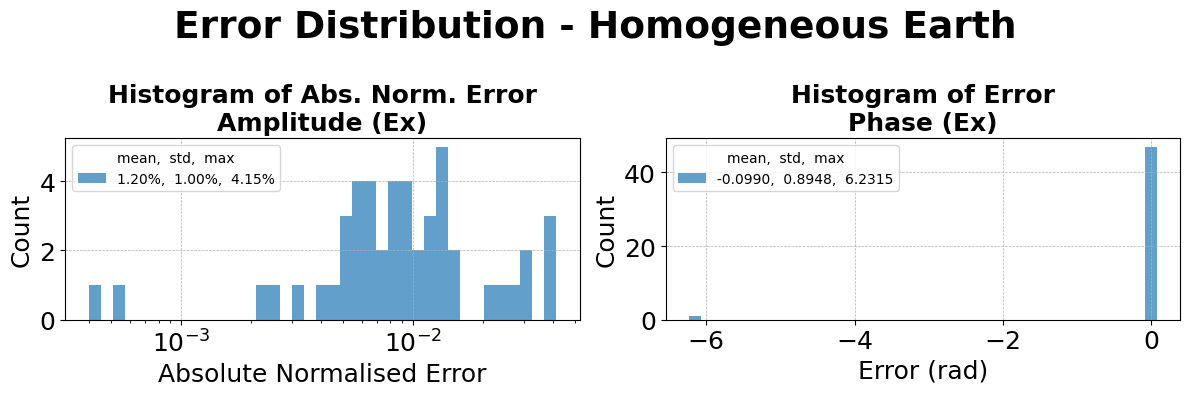

In [11]:
ErrorHistogramPlot([ef], reference=semi_analytical).plot(suptitle="Error Distribution - Homogeneous Earth")

## Printed error summary

In [ ]:
qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
for qi, name in enumerate(qty_names):
    err = field_error(semi_analytical, ef, qi)
    m, s, mx = error_stats(err)
    scale, unit = (100, '%') if qi != 1 else (1, 'rad')
    print(f'  {name:12s}:  mean={m*scale:.3f}{unit}  '
          f'std={s*scale:.3f}{unit}  max={mx*scale:.3f}{unit}')



── elfe3D  homogeneous earth ──
  Amplitude   :  mean=1.199%  std=0.998%  max=4.147%
  Phase       :  mean=-0.099rad  std=0.895rad  max=6.232rad
  Real        :  mean=2.457%  std=1.911%  max=9.570%
  Imaginary   :  mean=37.484%  std=183.618%  max=1291.444%
